In [1]:
# 1. Load data
# ===============================
# Step 1: Import necessary libraries
import pandas as pd   # For data manipulation
import numpy as np    # For numerical operations
import matplotlib.pyplot as plt  # For plotting

In [2]:
# Step 2: Load the dataset
# ===============================
df = pd.read_csv("C:/Users/User/OneDrive - Singapore Polytechnic/Desktop/AI ML/CA1-Dataset/CA1-Dataset/housing_price_data.csv")
# Read CSV file into a DataFrame

In [3]:
# 2. Explore the DataFrame
shape_of_df=df.shape
print(f'Shape: {shape_of_df}')

index_of_df=df.index
print(f'Index: {index_of_df}')

column_of_df=df.columns
print(f'Columns: {column_of_df}')

print('DataFrame info:')
df.info()

describe_of_df=df.describe()
print(f'Descriptive Statistics: {describe_of_df}')

head_of_df = df.head()
print(f'First 5 rows:\n{head_of_df}')

missing_of_df = df.isnull().sum()
print(f'Missing values per column:\n{missing_of_df}')

Shape: (545, 8)
Index: RangeIndex(start=0, stop=545, step=1)
Columns: Index(['House ID', 'City', 'House Area (sqm)', 'No. of Bedrooms',
       'No. of Toilets', 'Stories', 'Renovation Status', 'Price ($)'],
      dtype='object')
DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   House ID           545 non-null    int64  
 1   City               545 non-null    object 
 2   House Area (sqm)   545 non-null    float64
 3   No. of Bedrooms    545 non-null    int64  
 4   No. of Toilets     545 non-null    int64  
 5   Stories            545 non-null    int64  
 6   Renovation Status  545 non-null    object 
 7   Price ($)          545 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 34.2+ KB
Descriptive Statistics:         House ID  House Area (sqm)  No. of Bedrooms  No. of Toilets  \
count  545.00

### Dataset Overview
The dataset contains **545 rows and 8 columns**, representing house listings in different US cities. The target variable is **Price ($)**, which aims to predict.
  * **Numeric features:** House Area, No. of bedrooms, No. of toilets, Stories and Price.
  * **Categorical features:** City, Renovation Status
  * **House ID** is an identifier and will not be used as a predictive feature.

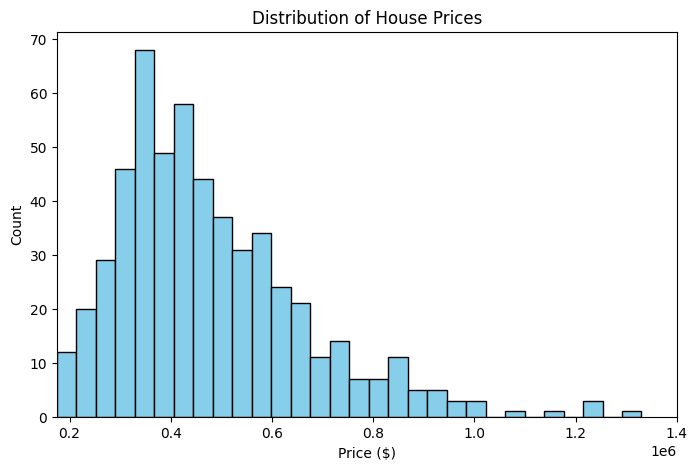

In [4]:
# Price distribution
plt.figure(figsize=(8,5))
plt.hist(df['Price ($)'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of House Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.xlim(175000,1400000)
plt.show()

### House Price Distribution

* The distribution of house prices is **right-skewed**, meaning most houses fall in the lower–mid price range while a smaller number have very high prices.
* The **most common price level is around 350,000**, with about **68 houses**.
* The **least frequent price level has only 1 house**, showing that extremely expensive listings are rare.

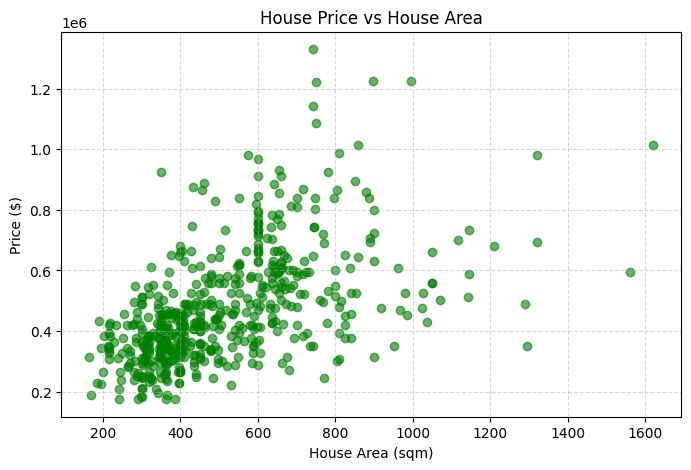

In [5]:
# Scatter plot: Price vs House Area
plt.figure(figsize=(8,5))
plt.scatter(df['House Area (sqm)'], df['Price ($)'], alpha=0.6, color='green')
plt.title("House Price vs House Area")
plt.xlabel("House Area (sqm)")
plt.ylabel("Price ($)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Price vs House Area (Scatter Plot)

* Most houses cluster within **300–650 sqm** in area and **200k–700k** in price.
* The points form a **broad upward trend**, suggesting larger houses generally cost more.
* The relationship is positive but not extremely strong or linear.
* There are some noticeable outliers (e.g., very large houses above 1200 sqm or priced above 1M but they do not change the overall moderate upward trend.

C:\Users\User\AppData\Local\Temp\ipykernel_152928\948914476.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(price_groups, labels=bedroom_counts)


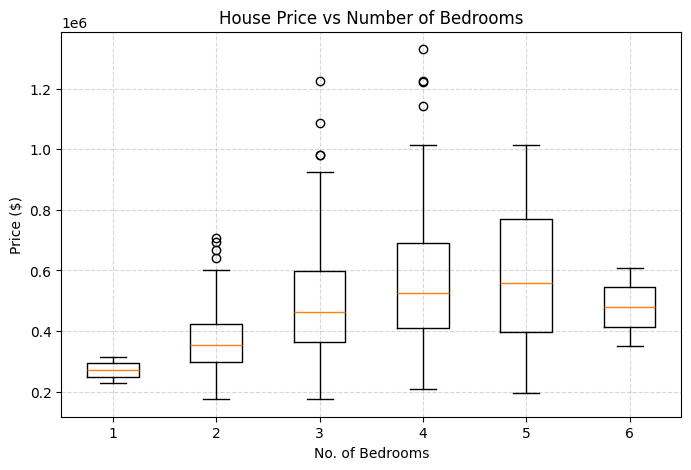

In [6]:
# Box plot: Price vs No. of Bedrooms
df_copy = df.copy()

# Get unique bedroom counts sorted
bedroom_counts = sorted(df_copy['No. of Bedrooms'].unique())

# Collect price lists by bedroom count
price_groups = [
    df_copy[df_copy['No. of Bedrooms'] == b]['Price ($)'].tolist()
    for b in bedroom_counts
]

plt.figure(figsize=(8,5))
plt.boxplot(price_groups, labels=bedroom_counts)
plt.title("House Price vs Number of Bedrooms")
plt.xlabel("No. of Bedrooms")
plt.ylabel("Price ($)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [7]:
# Get unique bedroom counts sorted
bedroom_counts = sorted(df['No. of Bedrooms'].unique())

for b in bedroom_counts:
    prices = df[df['No. of Bedrooms'] == b]['Price ($)']
    
    print(f"Bedrooms = {b}")
    print(f"  Count     : {len(prices)}")
    print(f"  Min       : {prices.min():,.0f}")
    print(f"  1.05th %ile : {np.percentile(prices, 1.05):,.0f}")
    print(f"  Median    : {prices.median():,.0f}")
    print(f"  75th %ile : {np.percentile(prices, 75):,.0f}")
    print(f"  Max       : {prices.max():,.0f}")
    print("-" * 40)

Bedrooms = 1
  Count     : 2
  Min       : 227,500
  1.05th %ile : 228,419
  Median    : 271,250
  75th %ile : 293,125
  Max       : 315,000
----------------------------------------
Bedrooms = 2
  Count     : 136
  Min       : 175,000
  1.05th %ile : 183,461
  Median    : 353,500
  75th %ile : 421,750
  Max       : 707,000
----------------------------------------
Bedrooms = 3
  Count     : 300
  Min       : 175,000
  1.05th %ile : 191,930
  Median    : 462,000
  75th %ile : 596,750
  Max       : 1,225,000
----------------------------------------
Bedrooms = 4
  Count     : 95
  Min       : 210,000
  1.05th %ile : 237,636
  Median    : 525,000
  75th %ile : 691,250
  Max       : 1,330,000
----------------------------------------
Bedrooms = 5
  Count     : 10
  Min       : 196,000
  1.05th %ile : 213,133
  Median    : 558,250
  75th %ile : 770,000
  Max       : 1,015,000
----------------------------------------
Bedrooms = 6
  Count     : 2
  Min       : 350,000
  1.05th %ile : 352,712
  M

### Insights
1. **General Trend**
- As the number of bedrooms increases, house prices generally increase.
- This pattern holds through almost all bedroom categories (1 to 6 bedrooms), suggesting that bedroom count is positively correlated with housing price.

2. **Price Distribution by Bedrooms**
- 1 Bedroom - Very small sample (n=2), so results are not very reliable.
- 2 Bedrooms - Sample size is good (n=136). Median price shows a wide spread of prices. Max price indicating that some 3-bedroom houses are in premium areas or have better features.
- 3 Bedrooms - Largest sample (n=300).Median price jumps to 462k. Max reaches 1.225M, the highest max across the dataset. Shows strong purchasing demand and value appreciation for 3-bedroom houses.
- 4 Bedrooms - Median increases to 525k. Still a wide price spread, indicating that house features and location significantly affect value in this category as well.
- 5 Bedrooms - Small sample (n=10), but trend continues. Upper range up to 1M
- 6 Bedrooms - Very small sample (n=2). Lower max than some 4–5 bedroom homes, showing that more bedrooms do not guarantee higher price—likely due to location or limited sampling.

3. **Key Takeaways**
- Price generally increases with more bedrooms, especially from 1 → 4 bedrooms.
- 3-bedroom properties show the widest value range, and the highest maximum price, indicating they may be the most demanded property type.
- Variation increases with bedrooms, meaning that:
- House price depends not only on number of rooms
- But also on location, land size, condition, and other features.
- **Bedrooms with very small samples (1 and 6) should be interpreted cautiously because the distribution is not statistically stable.**

City
New York    158
Seattle     134
Boston      105
Denver       89
Chicago      59
Name: count, dtype: int64
City
Boston      477780.000000
Chicago     503850.745763
Denver      504589.887640
New York    464753.481013
Seattle     459351.492537
Name: Price ($), dtype: float64


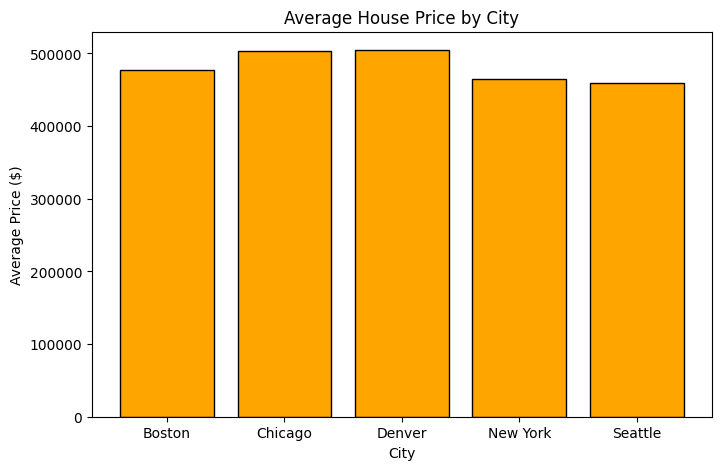

In [8]:
# Bar chart: Average Price by City
# Count of houses per city
house_count_city = df['City'].value_counts()
print(house_count_city)

avg_price_city = df.groupby('City')['Price ($)'].mean()
print(avg_price_city)

plt.figure(figsize=(8,5))
plt.bar(avg_price_city.index, avg_price_city.values, color='orange', edgecolor='black')
plt.title("Average House Price by City")
plt.xlabel("City")
plt.ylabel("Average Price ($)")
plt.show()

- The bar chart shows the average house price in each cit
= Highest average price: Denver (504,590) and Chicago (503,851)
- Lowest average price: Seattle (459,350) and New York (464,750)
- Observation: There is noticeable variation across cities, with Denver and Chicago being more expensive on average than Boston, New York, and Seattle.

Renovation Status
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64
Renovation Status
furnished         549569.600000
semi-furnished    490752.422907
unfurnished       401383.146067
Name: Price ($), dtype: float64


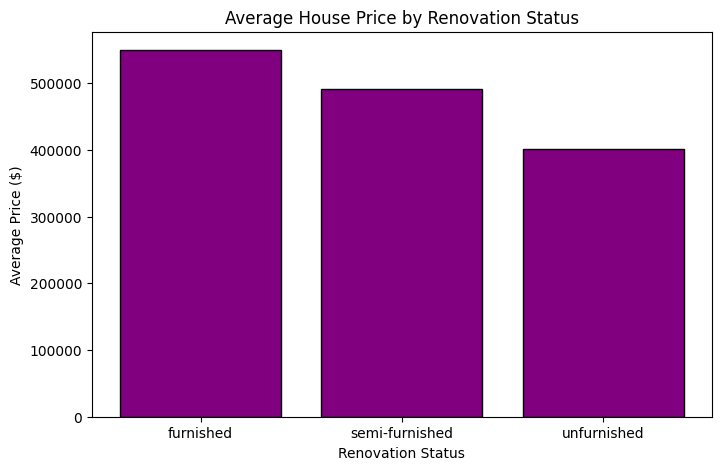

In [9]:
# Bar chart: Average Price by Renovation Status
reno_count = df['Renovation Status'].value_counts()
print(reno_count)

avg_price_reno = df.groupby('Renovation Status')['Price ($)'].mean()
print(avg_price_reno)
plt.figure(figsize=(8,5))
plt.bar(avg_price_reno.index, avg_price_reno.values, color='purple', edgecolor='black')
plt.title("Average House Price by Renovation Status")
plt.xlabel("Renovation Status")
plt.ylabel("Average Price ($)")
plt.show()

- This bar chart shows that house prices vary by renovation status.
- Furnished houses tend to have the highest average prices, followed by semi-furnished, while unfurnished houses generally have the lowest average prices.
- This suggests that the level of furnishing is positively correlated with house price.

In [10]:
# 3. Clean 
# ===============================
df.isnull().sum()

House ID             0
City                 0
House Area (sqm)     0
No. of Bedrooms      0
No. of Toilets       0
Stories              0
Renovation Status    0
Price ($)            0
dtype: int64

### 3.1 Handle Missing Values
- Checked for missing values in all columns:
  - `House ID`, `City`, `House Area (sqm)`, `No. of Bedrooms`, `No. of Toilets`, `Stories`, `Renovation Status`, `Price ($)`  
- No missing values were found, so no imputation or deletion is needed.

### 3.2 Fix Data Types
- `House ID` : int64 → numeric
- `City` : object → categorical  
- `House Area (sqm)` : float64 → numeric  
- `No. of Bedrooms`, `No. of Toilets`, `Stories` : int64 → numeric  
- `Renovation Status` : object → categorical  
- `Price ($)` : int64 → numeric  
- Data types are appropriate, no conversion needed.

### 3.3 Remove Outliers
- Observed `Price ($)` and `House Area (sqm)` distributions:
  - Extreme values exist at the high end (Price > 1,000,000; Area > 1,200 sqm), which are rare and may affect model performance.
- Use **IQR method** to filter out outliers

In [11]:
# Copy original dataframe
df_clean = df.copy()

# Define which bedroom groups to remove outliers for
groups_to_clean = [2, 3, 4]

# Iterative function to remove upper outliers
def remove_upper_outliers_iterative(group):
    while True:
        Q1 = group['Price ($)'].quantile(0.25)
        Q3 = group['Price ($)'].quantile(0.75)
        IQR = Q3 - Q1
        upper_bound = Q3 + 1.5 * IQR
        new_group = group[group['Price ($)'] <= upper_bound]
        if new_group.shape[0] == group.shape[0]:  # no more outliers
            break
        group = new_group
    return group

# Apply only to the selected groups
df_clean = df_clean.groupby('No. of Bedrooms', group_keys=False).apply(
    lambda g: remove_upper_outliers_iterative(g) if g.name in groups_to_clean else g
).reset_index(drop=True)

# Check new shape
print("Original shape:", df.shape)
print("New shape after removing all upper outliers for Bedrooms 2, 3, 4:", df_clean.shape)

Original shape: (545, 8)
New shape after removing all upper outliers for Bedrooms 2, 3, 4: (529, 8)


C:\Users\User\AppData\Local\Temp\ipykernel_152928\1009020296.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby('No. of Bedrooms', group_keys=False).apply(


C:\Users\User\AppData\Local\Temp\ipykernel_152928\2567646515.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(price_groups, labels=bedroom_counts)


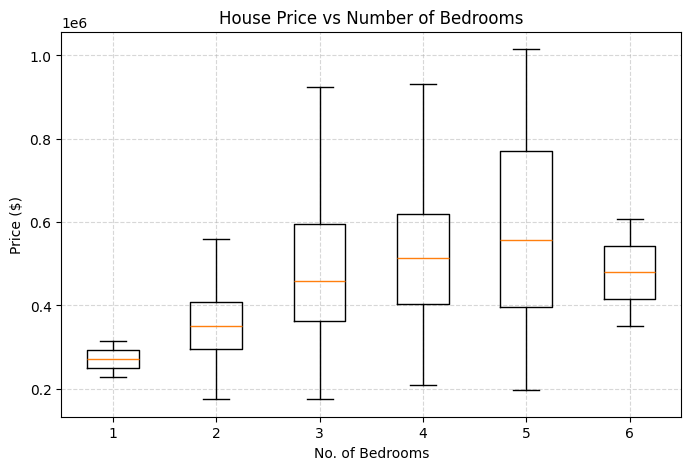

In [12]:
bedroom_counts = sorted(df_clean['No. of Bedrooms'].unique())

price_groups = [
    df_clean[df_clean['No. of Bedrooms'] == b]['Price ($)'].tolist()
    for b in bedroom_counts
]

plt.figure(figsize=(8,5))
plt.boxplot(price_groups, labels=bedroom_counts)
plt.title("House Price vs Number of Bedrooms")
plt.xlabel("No. of Bedrooms")
plt.ylabel("Price ($)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [13]:
bedroom_counts = [2, 3, 4]

for b in bedroom_counts:
    prices = df_clean[df_clean['No. of Bedrooms'] == b]['Price ($)']
    print(f"Bedrooms = {b}")
    print(f"  Count     : {len(prices)}")
    print(f"  Min       : {prices.min():,.0f}")
    print(f"  1.05th %ile : {np.percentile(prices, 1.05):,.0f}")
    print(f"  Median    : {prices.median():,.0f}")
    print(f"  75th %ile : {np.percentile(prices, 75):,.0f}")
    print(f"  Max       : {prices.max():,.0f}")
    print("-" * 40)

Bedrooms = 2
  Count     : 131
  Min       : 175,000
  1.05th %ile : 183,278
  Median    : 350,000
  75th %ile : 409,500
  Max       : 560,000
----------------------------------------
Bedrooms = 3
  Count     : 296
  Min       : 175,000
  1.05th %ile : 191,048
  Median    : 458,500
  75th %ile : 595,000
  Max       : 924,000
----------------------------------------
Bedrooms = 4
  Count     : 88
  Min       : 210,000
  1.05th %ile : 235,578
  Median    : 512,750
  75th %ile : 618,625
  Max       : 931,000
----------------------------------------


### Outlier Removal

To reduce the influence of extreme high prices on the analysis, I removed only the **upper outliers** for houses with **2, 3, and 4 bedrooms**. This decision was based on the box plot, which showed that these groups had clear extreme high values. 

I used an **iterative IQR method**:

1. For each bedroom group, calculate the first quartile (Q1) and third quartile (Q3).
2. Compute the interquartile range (IQR = Q3 - Q1).
3. Define the upper bound as `Q3 + 1.5 * IQR`.
4. Remove all houses with prices above this upper bound.
5. Repeat steps 1–4 until no more upper outliers remain.

Other bedroom groups (1, 5, 6) were left unchanged because they either had **no clear outliers** or **very few data points**, so removing outliers could distort the data.  

After cleaning, the dataframe shape changed from **(545, 8)** to the new shape as printed by the code.

In [14]:
# 4. Prepare features 
# ===============================
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Select Features and Target
X = df_clean.drop(['House ID', 'Price ($)'], axis=1)
y = df_clean['Price ($)']

# Identify column types
numeric_features = ['House Area (sqm)', 'No. of Bedrooms', 'No. of Toilets', 'Stories']
categorical_features = ['City', 'Renovation Status']

# Define transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

### Feature Preparation
To prepare the dataset for modeling, I selected the following meaningful input features:
* **House Area, Bedrooms, Toilets, Stories**
  These numeric variables strongly influence house value and are retained as continuous inputs.
* **City and Renovation Status**
  These are categorical variables and need to be encoded before being used in a regression model.
`House ID` was removed because it is only an identifier and does not provide predictive information.

### Encoding
Categorical features (City and Renovation Status) were transformed using **One-Hot Encoding**, because regression models cannot operate directly on text labels. One category was dropped (`drop='first'`) to avoid multicollinearity.

### Scaling
Numeric features were standardized using **StandardScaler**, which gives them zero mean and unit variance. This improves stability and performance for many models such as Linear Regression, Ridge, Lasso, and Gradient Boosting.

### Result
The final design matrix now contains clean numeric inputs suitable for machine learning regression models.

In [15]:
# 5. Choose algorithms 
# ===============================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

# Linear Regression (scaling needed)
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Ridge Regression (scaling needed)
pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

# Lasso Regression (scaling needed)
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.1, random_state=42, max_iter=5000))
])

# Decision Tree Regressor (scaling not required)
pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Random Forest Regressor (scaling not required)
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Gradient Boosting Regressor (scaling not required)
pipeline_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

# Support Vector Regressor (scaling needed)
pipeline_svr = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=100, epsilon=0.1))
])

### Algorithm Selection – Reasoning
* **Linear Regression** – Simple baseline; interpretable; captures linear relationships.
* **Ridge / Lasso** – Linear with regularization; helps reduce overfitting and handle multicollinearity.
* **Decision Tree Regressor** – Captures nonlinear relationships; no need for feature scaling.
* **Random Forest Regressor** – Ensemble of trees; reduces overfitting; handles complex patterns.
* **Gradient Boosting Regressor** – Boosted trees; strong predictive power; handles nonlinearities.
* **Support Vector Regressor (SVR)** – Effective for small-to-medium datasets; captures nonlinear patterns with kernels; requires feature scaling.

In [16]:
# 6. Train and test 
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Split data
X = df_clean.drop(columns=['Price ($)', 'House ID'])  # features
y = df_clean['Price ($)']  # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define pipelines
pipelines = {
    'Linear Regression': Pipeline([('preprocessor', preprocessor), 
                                   ('regressor', LinearRegression())]),
    'Ridge': Pipeline([('preprocessor', preprocessor), 
                       ('regressor', Ridge(alpha=1.0, random_state=42))]),
    'Lasso': Pipeline([('preprocessor', preprocessor), 
                       ('regressor', Lasso(alpha=0.01, random_state=42))]),
    'Decision Tree': Pipeline([('preprocessor', preprocessor), 
                               ('regressor', DecisionTreeRegressor(random_state=42))]),
    'Random Forest': Pipeline([('preprocessor', preprocessor), 
                               ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))]),
    'Gradient Boosting': Pipeline([('preprocessor', preprocessor), 
                                   ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))]),
    'SVR': Pipeline([('preprocessor', preprocessor), 
                     ('regressor', SVR(kernel='rbf'))])
}

# Train, predict, and evaluate
results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

# 4. Show results
results_df = pd.DataFrame(results).sort_values('RMSE')
print(results_df)

               Model           RMSE            MAE        R2
1              Ridge  107961.448416   82175.253529  0.572958
2              Lasso  108196.018979   82413.346306  0.571100
0  Linear Regression  108196.057399   82413.376403  0.571100
4      Random Forest  110677.810829   82593.895472  0.551199
5  Gradient Boosting  117346.347334   85057.670389  0.495487
3      Decision Tree  159158.061269  120918.396226  0.071909
6                SVR  170753.027399  128188.385613 -0.068243


### Analysis:
- Best Models: Ridge regression performed slightly better than Lasso and Linear Regression, achieving the lowest RMSE and highest R² (~0.573), indicating it explains ~57% of the variance in house prices.
- Moderate Performance: Random Forest and Gradient Boosting have slightly higher errors and lower R², possibly due to limited data and default hyperparameters.
- Poor Models: Decision Tree and SVR performed poorly. Decision Tree overfits the training data, while SVR underfits, leading to very low or negative R².
- Reasoning: The linear models work best because house prices have a moderately linear relationship with the selected features, and regularization in - Ridge helps reduce overfitting.
- This comparison suggests that Ridge regression is the most suitable model for predicting housing prices in this dataset.

In [17]:
# 7. Tune
# ===============================
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define objective function for Optuna
def objective(trial):
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=alpha, random_state=42))
    ])
    
    # 5-fold cross-validation RMSE
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, 
        X_train, y_train, 
        scoring='neg_root_mean_squared_error', 
        cv=cv
    )
    return -np.mean(scores)  # Optuna minimizes the objective

# Create study and optimize
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=100)

# Best hyperparameters
print("Best alpha:", study.best_params['alpha'])
print("Best CV RMSE:", study.best_value)

# Train final model
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=study.best_params['alpha'], random_state=42))
])
best_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:,.2f}")
print(f"Test MAE: {mae:,.2f}")
print(f"Test R2: {r2:.3f}")

C:\Users\User\anaconda3\envs\AIML2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-12-02 10:11:45,946] A new study created in memory with name: no-name-83f62a0f-d50a-4e6d-aed2-eb665a6ee6c2
[I 2025-12-02 10:11:46,044] Trial 0 finished with value: 117042.81048092218 and parameters: {'alpha': 0.31489116479568624}. Best is trial 0 with value: 117042.81048092218.
[I 2025-12-02 10:11:46,129] Trial 1 finished with value: 117045.68052672064 and parameters: {'alpha': 63.512210106407046}. Best is trial 0 with value: 117042.81048092218.
[I 2025-12-02 10:11:46,209] Trial 2 finished with value: 116645.18889201668 and parameters: {'alpha': 8.471801418819979}. Best is trial 2 with value: 116645.18889201668.
[I 2025-12-02 10:11:46,288] Trial 3 finished with value: 116884.9442307943 and parameters: {'alpha': 2.481040974867

Best alpha: 21.312298073011387
Best CV RMSE: 116517.32395673364
Test RMSE: 105,543.11
Test MAE: 79,115.36
Test R2: 0.592


### Analysis
- RMSE decreased slightly, predictions closer to actual prices.
- MAE decreased, indicating smaller median error.
- R² increased from 0.573 → 0.592, meaning the model explains more variance in house prices.
- Hyperparameter tuning helped **moderately improve** Ridge regression performance.

### Insights
- Regularized linear models (Ridge) are well-suited for this dataset.
- Adjusting alpha prevents overfitting to high-priced houses while retaining predictive power.

In [18]:
# 8. Check feature importance  
# ===============================
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

coef = best_model.named_steps['regressor'].coef_

coef_df = (
    pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    })
    .sort_values(by='Coefficient', ascending=False)
)

print(coef_df)

                                 Feature   Coefficient
0                  num__House Area (sqm)  62469.981518
3                           num__Stories  45928.084345
2                    num__No. of Toilets  45037.604249
1                   num__No. of Bedrooms  14358.328939
6                     cat__City_New York  -1416.849192
7                      cat__City_Seattle  -2163.668502
5                       cat__City_Denver  -6131.464115
8  cat__Renovation Status_semi-furnished  -8074.704342
4                      cat__City_Chicago  -8113.719379
9     cat__Renovation Status_unfurnished -55132.329144


### Feature Importance Insights

The Ridge regression model with engineered features and tuned alpha shows the following:

- **Renovation Status** – has the largest impact on house price. Furnished and semi-furnished homes are generally more expensive, while unfurnished homes reduce predicted price significantly.  
- **House Area (sqm)** – larger houses tend to command higher prices, making this one of the most important numerical features.  
- **Stories** – houses with more stories are generally priced higher, reflecting added value from additional floors.  
- **Number of Toilets** – contributes positively to price, though less than area or stories.  
- **City** – location influences pricing. Some cities like Chicago or Denver increase predicted price, while New York and Seattle have lower coefficients.  
- **Number of Bedrooms** – has a smaller impact compared to the other features, suggesting that room count alone is not the dominant factor.  

**Conclusion:**  
Renovation status and house area are the most critical factors affecting house price in this dataset, while stories, toilets, and location also provide meaningful contributions.  

In [19]:
# 9. Improve
# ===============================
# Complete Ridge Regression Pipeline with Derived Features + Optuna

X = df_clean.drop(columns=['Price ($)', 'House ID'])
y = df_clean['Price ($)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def add_features(df):
    df = df.copy()
    df['Stories_x_Area'] = df['Stories'] * df['House Area (sqm)']
    df['Large_House'] = (df['House Area (sqm)'] > 600).astype(int)
    df['Area_per_Bedroom'] = df['House Area (sqm)'] / df['No. of Bedrooms']
    df['Area_per_Toilet'] = df['House Area (sqm)'] / df['No. of Toilets']
    df['Stories_per_Area'] = df['Stories'] / df['House Area (sqm)']
    df['log_Area'] = np.log1p(df['House Area (sqm)'])
    return df

X_train = add_features(X_train)
X_test = add_features(X_test)

categorical_features = ['City', 'Renovation Status', 'Large_House']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

def objective(trial):
    alpha = trial.suggest_float('alpha', 0.001, 1000.0, log=True)
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=alpha, random_state=42))
    ])
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, 
                             scoring='neg_root_mean_squared_error', cv=cv)
    return -np.mean(scores)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100)

best_alpha = study.best_params['alpha']
best_cv_rmse = study.best_value

print(f"Best alpha: {best_alpha:.4f}")
print(f"Best CV RMSE: {best_cv_rmse:.2f}")

pipeline_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=best_alpha, random_state=42))
])

pipeline_tuned.fit(X_train, y_train)
y_pred = pipeline_tuned.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_mae = mean_absolute_error(y_test, y_pred)
final_r2 = r2_score(y_test, y_pred)

print("\n=== Tuned Ridge Regression ===")
print(f"RMSE: {final_rmse:,.2f}")
print(f"MAE: {final_mae:,.2f}")
print(f"R²: {final_r2:.3f}")

[I 2025-12-02 10:11:54,679] A new study created in memory with name: no-name-a4a07da6-97c3-45b2-9466-844481ab4ad1
[I 2025-12-02 10:11:54,788] Trial 0 finished with value: 113973.65635102728 and parameters: {'alpha': 0.1767016940294795}. Best is trial 0 with value: 113973.65635102728.
[I 2025-12-02 10:11:54,902] Trial 1 finished with value: 122576.05049179056 and parameters: {'alpha': 506.1576888752306}. Best is trial 0 with value: 113973.65635102728.
[I 2025-12-02 10:11:55,002] Trial 2 finished with value: 113635.24148750375 and parameters: {'alpha': 24.658329458549105}. Best is trial 2 with value: 113635.24148750375.
[I 2025-12-02 10:11:55,114] Trial 3 finished with value: 113142.72281683532 and parameters: {'alpha': 3.907967156822881}. Best is trial 3 with value: 113142.72281683532.
[I 2025-12-02 10:11:55,223] Trial 4 finished with value: 114153.84564903933 and parameters: {'alpha': 0.008632008168602538}. Best is trial 3 with value: 113142.72281683532.
[I 2025-12-02 10:11:55,330] Tri

Best alpha: 6.5196
Best CV RMSE: 113081.17

=== Tuned Ridge Regression ===
RMSE: 102,816.14
MAE: 77,794.40
R²: 0.613


# Improve: Feature Engineering & Model Tuning
### Derived Features Added
I added several derived features to help the model capture non-linear and interaction effects:

- **Stories × House Area (`Stories_x_Area`)** – captures the combined effect of house size and number of stories.  
- **Large_House** – binary indicator if the house area exceeds 600 sqm.  
- **Area per Bedroom (`Area_per_Bedroom`)** – average area allocated per bedroom.  
- **Area per Toilet (`Area_per_Toilet`)** – average area allocated per toilet.  
- **Stories per Area (`Stories_per_Area`)** – ratio of number of stories to house area.  
- **Log of House Area (`log_Area`)** – logarithmic transformation to reduce skewness and capture diminishing returns of large areas.  

### Hyperparameter Tuning (Optuna)
- Searched the `alpha` hyperparameter for Ridge Regression using Optuna.
- Performed 5-fold cross-validation to minimize RMSE.
- Found best alpha ≈ **6.52**.
- Cross-validated RMSE ≈ **113,081**.

### After Tuning + Derived Features
| Metric | Baseline | Tuned |
|--------|----------|-------|
| RMSE   | 107，961 | 102,816|
| MAE    | 82，175  | 77,794|
| R²     | 0.573    | 0.613 |

### Analysis & Insights
- **Improvement:** RMSE and MAE decreased slightly, R² increased from 0.573 → 0.613.
- **Interpretation:** The model explains ~61% of variance in house prices after tuning and adding derived features.
- **Regularization Effect:** Moderate alpha (6.52) prevents overfitting while retaining predictive power.
- **Conclusion:** Feature engineering + hyperparameter search improves model performance, and regularized linear models remain the best choice for this dataset.